## Predicting Insurance Claim Amounts

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#####  Load dataset

In [2]:
insurance = pd.read_csv('insurance.csv')

In [3]:
print(insurance.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


####  Encode categorical columns

In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

insurance['sex'] = encoder.fit_transform(insurance['sex'])
insurance['smoker'] = encoder.fit_transform(insurance['smoker'])
insurance['region'] = encoder.fit_transform(insurance['region'])

### Visualizations

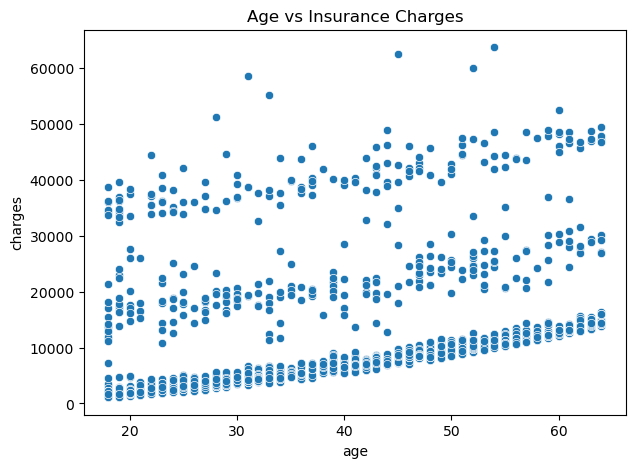

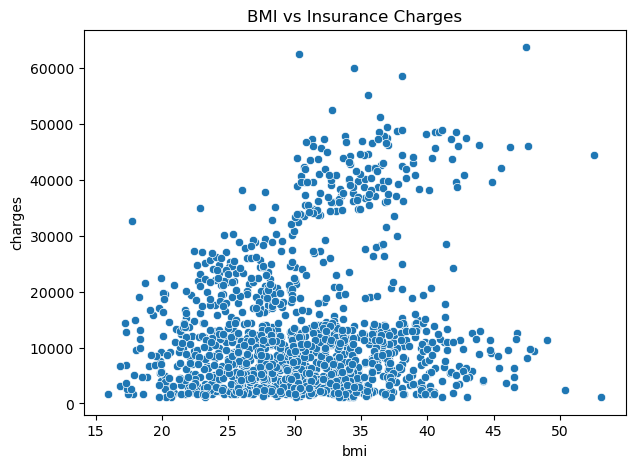

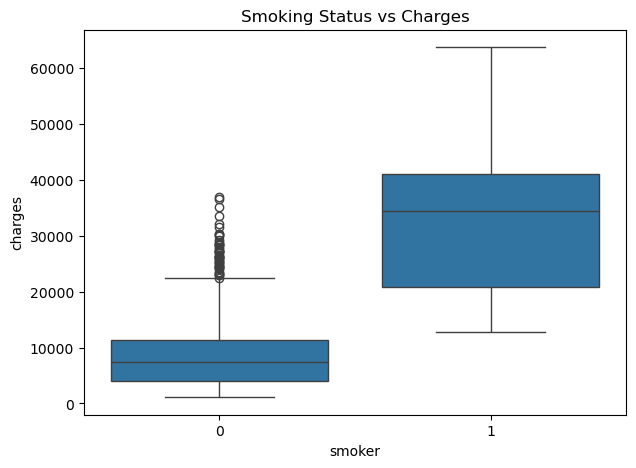

In [6]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=insurance, x='age', y='charges')
plt.title('Age vs Insurance Charges')
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=insurance, x='bmi', y='charges')
plt.title('BMI vs Insurance Charges')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(data=insurance, x='smoker', y='charges')
plt.title('Smoking Status vs Charges')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### Features and target 

In [16]:
X = insurance.drop('charges', axis=1)
y = insurance['charges']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Training model

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predicting Insurance Claims

In [21]:
predictions = model.predict(X_test)

In [22]:
print(model.predict(X_test))

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079  10790.77956153   226.29844571 16942.71599941
  1056.63079407 11267.91997309 28048.59793155  9424.36324087
  5326.32232088 38460.06017922 40303.40597026 37147.01010262
 15287.91876684 35965.05485917  9179.1753067  31510.8319849
  3797.79068365 10070.82803304  2312.57551348  7074.41348194
 11352.37224357 12907.77079523 14448.84678727  6205.65997921
  9917.00839638  2239.50032819  9060.55469043 13120.56214535
  4617.70702822  3467.91218926  4402.74821855 12967.91608907
  1927.44498944  8757.9180081  33324.35180597 32638.47697026
  3852.41756615  4370.39670883 14080.76023234 11478.63402576
  8829.26135924 12046.15119133  5322.80515731  3100.71182484
 35546.60547574  9201.61196817 15894.23763341  2406.04003607
 12397.52052544  1433.90617387 13448.14094304 12519.54174599
  4295.28664609 32202.67982224 13263.171278   12842.10998145
 14111.93665793 10551.59361363 16298.16745307  7818.15570419
 11787.5726767   4113.268

In [20]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4186.508898366434
RMSE: 5799.587091438356


In [23]:
from sklearn.metrics import r2_score

# R2 Score
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.7833463107364539
